# AutoML Lab · forecasting engine — Time-series demo

A fully automated forecasting workflow for **single or multi-series
(panel) data**: point it at a long-format frame (date, series ID, target),
set the horizon, Run All — get backtested forecasts with prediction intervals
and a deployable artifact back.

This notebook is a thin, narrated driver; the logic lives in the importable,
unit-tested [`autofc` package](../autofc/) one directory up.

| Stage | What happens |
|---|---|
| `load` | panel guardrails (frequency inference, duplicate timestamps, gap interpolation, short/constant series), bias-corrected seasonal-strength detection |
| `backtest` | every model evaluated with rolling-origin backtests: naive / seasonal-naive / drift baselines, auto-SARIMAX, ETS, Theta, Prophet, global LightGBM/XGBoost/HistGB lag models, top-3 blend |
| `forecast` | champion refit on all data → final forecast with prediction intervals |
| `export` | model bundle, forecast CSV, generated `forecast.py` CLI, metadata, HTML report |

**Leaderboard honesty:** the primary metric is **MASE** (scale-free; < 1 means
"beats one-step seasonal-naive"), baselines always compete, and the engine
warns loudly when the champion barely improves on seasonal-naive — the single
most common self-deception in forecasting.

**Demo dataset:** hourly electricity load for the 8 ERCOT regions of Texas
(2004–2021, ~155k rows), aggregated to daily and trimmed to 2016+ — strong
weekly and yearly seasonality, 8 related series that sum to a state total
(perfect for hierarchical reconciliation), US holidays, real operational data.

**Runtime:** ~2–3 minutes on 4 cores. `ForecastConfig.fast(...)` gives a
2-minute first pass.

## 0 · Configuration

In [1]:
import sys
sys.path.insert(0, "..")                     # notebooks/ -> repo folder with autofc/

from autofc import AutoForecast, ForecastConfig

REGIONS = ["COAST", "EAST", "FAR_WEST", "NORTH", "NORTH_C",
           "SOUTHERN", "SOUTH_C", "WEST"]

CONFIG = ForecastConfig(
    # ----- the three knobs that define the problem --------------------------
    horizon=28,                              # forecast 28 days ahead
    series_col="series",                     # None for a single series
    # date_col="ds", target="y"              (defaults)

    # ----- calendars & hierarchy ---------------------------------------------
    country_holidays="US",                   # holiday features for ML/SARIMAX/Prophet
    hierarchy={"ERCOT_TOTAL": REGIONS},      # total synthesized & forecasts reconciled
    reconciliation="auto",                   # best of bottom_up/ols/wls_struct/mint

    # ----- evaluation --------------------------------------------------------
    n_backtests=3,                           # rolling-origin folds
    interval_level=0.90,

    artifact_dir="artifacts_forecasting",
)

fc = AutoForecast(CONFIG)

/usr/local/lib/python3.11/dist-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 1 · Load data

The demo pulls the ERCOT regional load data, aggregates hourly → daily means, trims to 2016+, and melts the wide region columns into the long format the engine expects. Point the loader at your own long-format frame instead and delete the demo branch.

In [2]:
import pandas as pd
from autofc import from_wide

ERCOT_URL = ("https://raw.githubusercontent.com/ourownstory/neuralprophet-data/"
             "main/datasets/multivariate/load_ercot_regions.csv")

raw = pd.read_csv(ERCOT_URL)
raw["ds"] = pd.to_datetime(raw["ds"])
daily = raw.set_index("ds").resample("D").mean().reset_index()
daily = daily[(daily.ds >= "2016-01-01") & (daily.ds < "2021-09-01")]
df = from_wide(daily, "ds")                  # -> columns: ds, series, y

print(f"{df.series.nunique()} series x {df.ds.nunique():,} days = {len(df):,} rows")
df.head()

8 series x 2,070 days = 16,560 rows


,ds,series,y
0,2016-01-01,COAST,9649.025417
1,2016-01-02,COAST,9920.864583
2,2016-01-03,COAST,9882.477917
3,2016-01-04,COAST,9794.692083
4,2016-01-05,COAST,10384.402917


### A first look at the panel

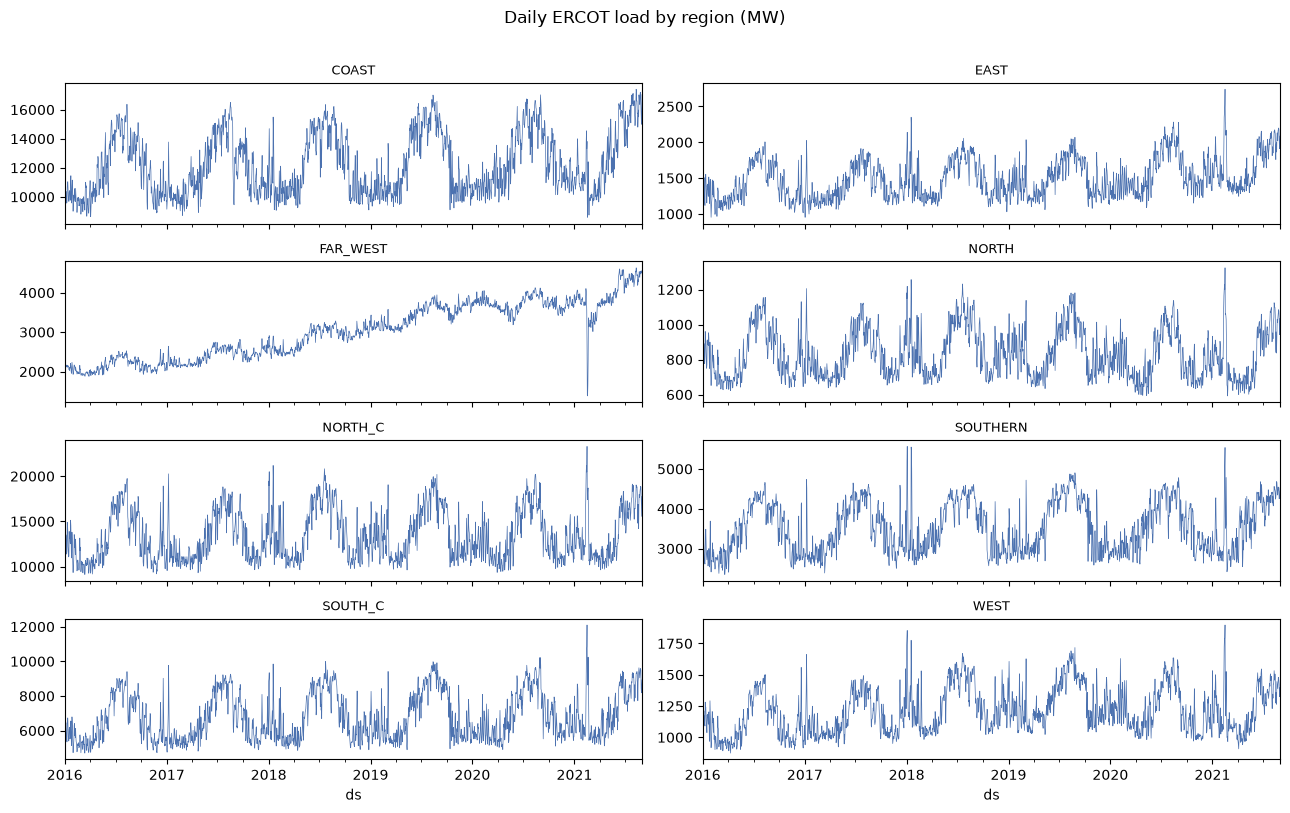

In [3]:
import matplotlib.pyplot as plt

wide = df.pivot(index="ds", columns="series", values="y")
axes = wide.plot(subplots=True, layout=(4, 2), figsize=(13, 8), lw=0.5,
                 color="#4C72B0", legend=False)
for ax, name in zip(axes.flat, wide.columns):
    ax.set_title(name, fontsize=9)
plt.suptitle("Daily ERCOT load by region (MW)", y=1.01)
plt.tight_layout(); plt.show()

## 2 · Panel guardrails & seasonality

Frequency is inferred per series and must agree across the panel; duplicate timestamps are aggregated, small gaps time-interpolated, and series that are too short, too gappy, or constant are dropped **with the reason logged**. Seasonal periods are calendar candidates (weekly and yearly for daily data) confirmed by **bias-corrected seasonal strength** — the variance share explained by phase means after detrending, shrunk by the few-cycles baseline so a random walk can't fake a yearly cycle. The engine doesn't assume seasonality, it checks for it.

In [4]:
fc.load(df)

[data] Panel ready: 8 series, 16,560 rows, freq=D
[hierarchy] Synthesized parent 'ERCOT_TOTAL' as the sum of 8 children (2,070 common timestamps)
[calendar] Holiday calendar enabled (US): day-of/before/after indicators feed the ML models and SARIMAX; Prophet uses its built-in holidays
[seasonality] Detected seasonal period(s) [7, 365] (median seasonal strength: {7: 0.12, 365: 0.64}); primary = 7


,rows,start,end,mean,missing_filled_%
series,,,,,
COAST,2070,2016-01-01,2021-08-31,12241.95,0.0
EAST,2070,2016-01-01,2021-08-31,1492.97,0.0
FAR_WEST,2070,2016-01-01,2021-08-31,3030.07,0.0
NORTH,2070,2016-01-01,2021-08-31,831.95,0.0
NORTH_C,2070,2016-01-01,2021-08-31,13437.84,0.0
SOUTHERN,2070,2016-01-01,2021-08-31,3527.98,0.0
SOUTH_C,2070,2016-01-01,2021-08-31,6804.28,0.0
WEST,2070,2016-01-01,2021-08-31,1212.10,0.0
ERCOT_TOTAL,2070,2016-01-01,2021-08-31,42579.14,0.0


## 3 · Rolling-origin backtests — the leaderboard

Three cutoffs step back from the end of the panel; every model trains strictly before each cutoff and forecasts the next 28 days. No shuffling anywhere.

- **MASE** (primary): < 1 beats one-step seasonal-naive.
- **coverage**: should sit near the configured 90% — intervals that don't cover are decoration, not uncertainty.
- Statistical models fit per series in parallel (auto-SARIMAX selects orders once per series by AIC and reuses them across refits; yearly seasonality enters as Fourier regressors). ML models train **globally across all series** on leak-safe lag/rolling/calendar features — the M5-winning recipe for related series.

In [5]:
fc.backtest()

[roster] Roster (10 models): ['Naive', 'Drift', 'SeasonalNaive', 'ETS', 'Theta', 'AutoSARIMAX', 'Prophet', 'LightGBM_global', 'XGBoost_global', 'HistGB_global']
[backtest] Rolling-origin backtests: 3 fold(s), horizon 28, cutoffs ['2021-06-08', '2021-07-06', '2021-08-03']
  Naive              MASE=1.258  WAPE=9.152%  (0.1s)
  Drift              MASE=1.243  WAPE=9.077%  (0.1s)


  SeasonalNaive      MASE=1.384  WAPE=10.035%  (0.1s)


  ETS                MASE=1.230  WAPE=9.036%  (4.7s)


  Theta              MASE=1.320  WAPE=9.670%  (5.3s)


/usr/local/lib/python3.11/dist-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


...

  Prophet            MASE=1.000  WAPE=6.525%  (6.6s)


  LightGBM_global    MASE=1.074  WAPE=7.502%  (12.9s)


  XGBoost_global     MASE=1.072  WAPE=7.632%  (11.2s)


  HistGB_global      MASE=1.032  WAPE=7.303%  (11.6s)
  Blend(Prophet, HistGB_global, XGBoost_global) MASE=0.961
[backtest] Deployment pick: the leaderboard winner itself — no candidate with fewer models sits within one standard error of its MASE
[backtest] Champion: Blend(Prophet, HistGB_global, XGBoost_global) (mean MASE=0.961)


,model,MASE,sMAPE,WAPE,RMSE,MAE,coverage,time_s
1,"Blend(Prophet, HistGB_global, XGBoost_global)",0.9612,0.0672,0.0660,1011.8531,854.8756,NaN,0.0
2,Prophet,0.9995,0.0660,0.0652,851.6086,759.0969,0.8796,6.6
3,HistGB_global,1.0321,0.0745,0.0730,1125.3340,925.0071,NaN,11.6
4,XGBoost_global,1.0725,0.0786,0.0763,1226.3821,1012.3397,NaN,11.2
5,LightGBM_global,1.0743,0.0772,0.0750,1136.5307,969.8196,NaN,12.9
6,ETS,1.2304,0.0943,0.0904,1219.2238,1062.1202,0.9881,4.7
7,Drift,1.2434,0.0945,0.0908,1198.0228,1044.1231,0.9881,0.1
8,Naive,1.2576,0.0954,0.0915,1210.0825,1056.3825,0.9868,0.1
9,Theta,1.3195,0.1014,0.0967,1283.2395,1128.1726,0.9868,5.3
10,SeasonalNaive,1.3835,0.1062,0.1004,1438.4879,1237.7384,0.9193,0.1


## 4 · Final forecast — with hierarchical reconciliation

The champion refits on the full panel and forecasts the next 28 days per region (plus the synthesized `ERCOT_TOTAL`), with prediction intervals (native where the model has them, backtest-residual bands otherwise — the report says which).

Because a hierarchy is configured, the engine then **reconciles** the forecasts: independently-forecast regions never sum exactly to the total, so bottom-up / OLS / structural-WLS / MinT-shrink projections are scored on the champion's own backtest folds (MinT's error covariance is estimated leave-fold-out) and the best one is applied — after which children sum *exactly* to their parents.

[forecast] WARNING: Blend(Prophet, HistGB_global, XGBoost_global): 90% residual bands are built from as few as 3 residual(s) per step (3 backtest fold(s)), which caps attainable coverage at ~75%. The bands are the widest the residuals support, but treat the nominal level as an upper bound — raise n_backtests to close the gap.
[forecast] Blend(Prophet, HistGB_global, XGBoost_global) has no native intervals -> 90% bands from per-series backtest residual quantiles


[reconcile] Applied 'bottom_up' reconciliation (selected automatically); pre-reconciliation coherency gap was 1.68% of the parent level; backtest MASE 0.961 -> 0.940. Intervals are translated with the point adjustment (widths unchanged).


[forecast] Final forecast: 28 steps x 9 series by Blend(Prophet, HistGB_global, XGBoost_global)


,ds,series,yhat,lo,hi
0,2021-09-01,COAST,16315.771899,15289.116840,17342.426958
1,2021-09-02,COAST,16075.198339,15048.543280,17101.853398
2,2021-09-03,COAST,16002.492358,14744.059032,17260.925684
3,2021-09-04,COAST,15674.185024,14071.823200,17276.546848
4,2021-09-05,COAST,15037.351676,13434.989852,16639.713500
5,2021-09-06,COAST,14957.444917,13194.923836,16719.965997
6,2021-09-07,COAST,15503.793799,13741.272718,17266.314880
7,2021-09-08,COAST,15660.519860,13897.998779,17423.040941
8,2021-09-09,COAST,15424.922564,13662.401483,17187.443644
9,2021-09-10,COAST,15089.968534,13327.447453,16852.489615


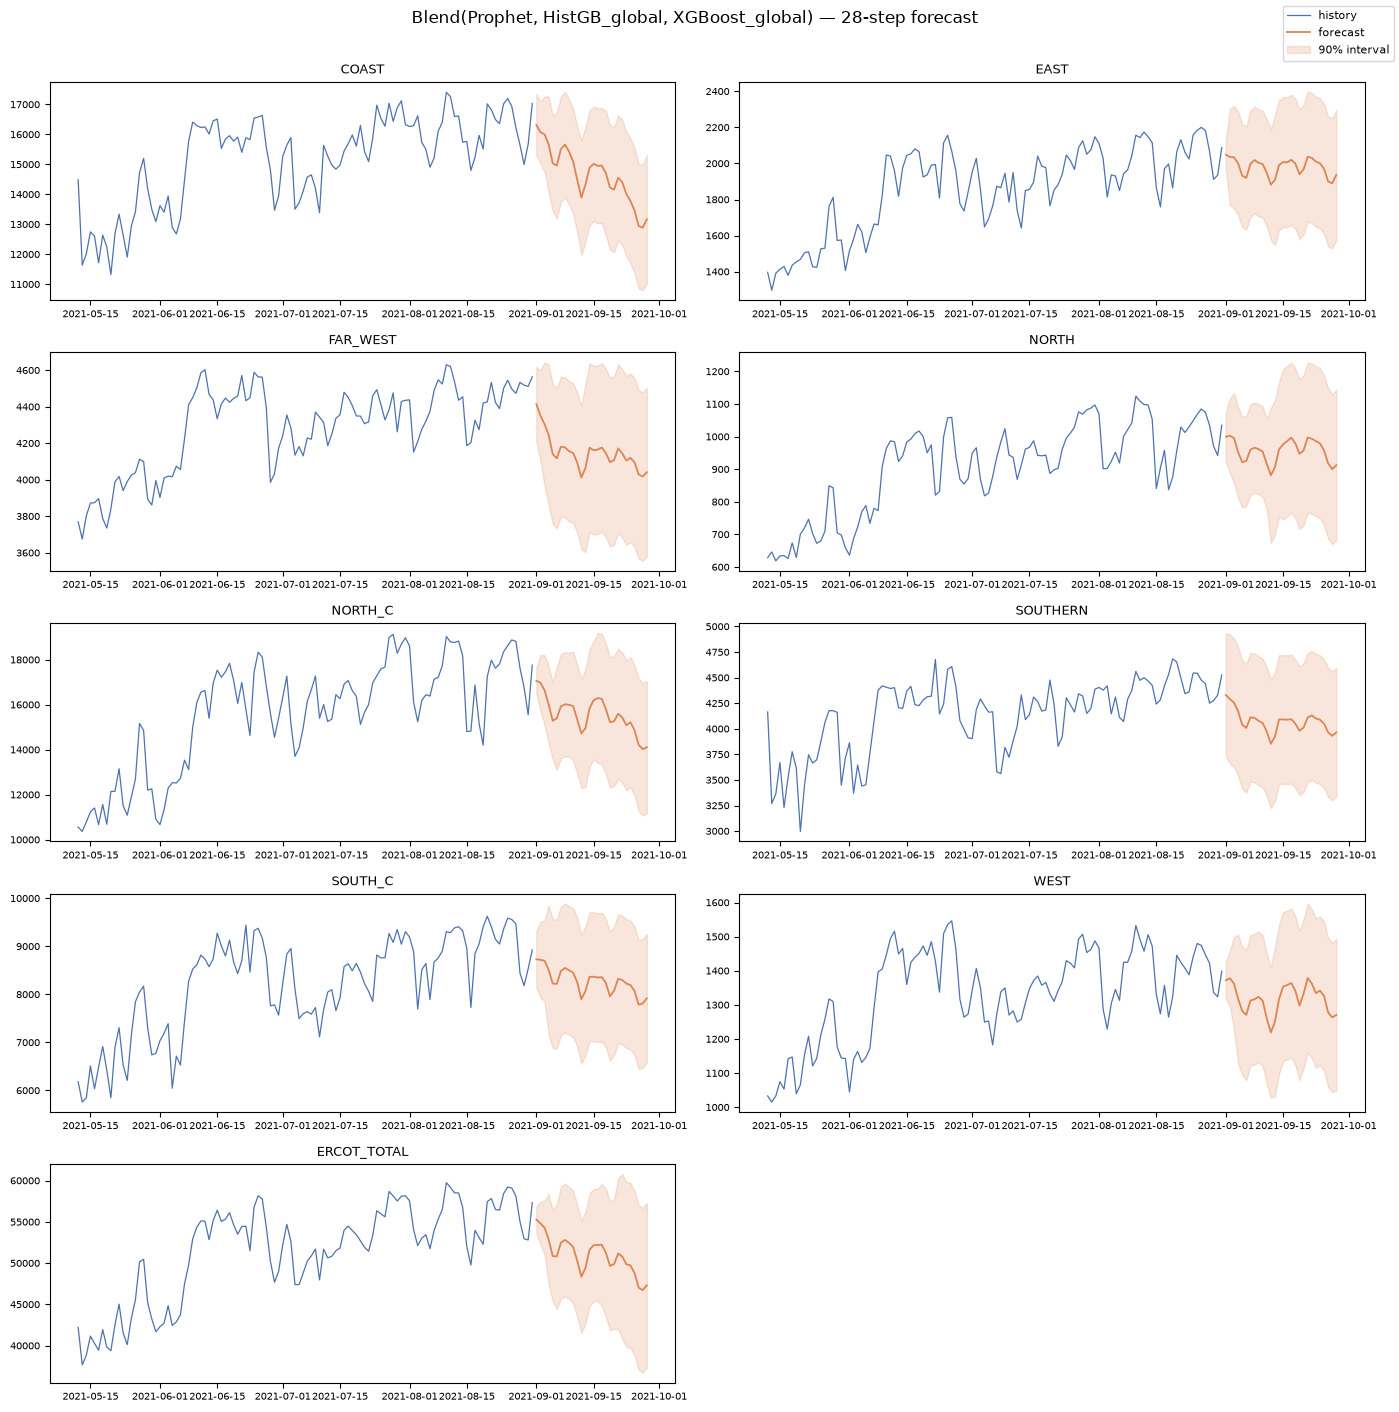

In [6]:
forecast = fc.forecast()
forecast.head(10)

## 5 · Export the artifact

```
artifacts_forecasting/
├── model.joblib      # fitted champion (blend members if a blend won)
├── forecast.csv      # the final forecast with intervals
├── forecast.py       # CLI: python forecast.py --output next.csv [--horizon H]
├── autofc/           # bundled package copy -> folder is self-contained
├── metadata.json     # panel, seasonality, leaderboard, decision log
├── requirements.txt  # pinned inference deps
└── report.html       # shareable report: leaderboard, plots, audit
```

In [7]:
artifact_dir = fc.export()
sorted(p.name for p in artifact_dir.iterdir())

[export] Total runtime: 5.4 min


[artifacts] forecast.py smoke test passed


[artifacts] Exported: model.joblib, metadata.json, forecast.csv, forecast.py, autofc/ (bundled package), report.html -> artifacts_forecasting/


['autofc',
 'forecast.csv',
 'forecast.py',
 'metadata.json',
 'model.joblib',
 'report.html',
 'requirements.txt']

## 6 · Decision audit

Everything the automation decided, in order — also shipped in `metadata.json` and `report.html`.

In [8]:
fc.log.to_frame()

,stage,decision
0,data,"Panel ready: 8 series, 16,560 rows, freq=D"
1,hierarchy,Synthesized parent 'ERCOT_TOTAL' as the sum of...
2,calendar,Holiday calendar enabled (US): day-of/before/a...
3,seasonality,"Detected seasonal period(s) [7, 365] (median s..."
4,roster,"Roster (10 models): ['Naive', 'Drift', 'Season..."
5,backtest,"Rolling-origin backtests: 3 fold(s), horizon 2..."
6,backtest,Deployment pick: the leaderboard winner itself...
7,backtest,"Champion: Blend(Prophet, HistGB_global, XGBoos..."
8,forecast,"WARNING: Blend(Prophet, HistGB_global, XGBoost..."
9,forecast,"Blend(Prophet, HistGB_global, XGBoost_global) ..."
